# 02 — IVF / IVF+PQ / IVF+SQ Benchmarks

We sweep the three Inverted-File index families that FAISS exposes:

* `IndexIVFFlat` — coarse quantiser + exact vectors per cell
* `IndexIVFPQ` — coarse quantiser + product-quantised residuals  (compressed)
* `IndexIVFScalarQuantizer` — coarse quantiser + per-component byte quantisation

The full base set (1 281 167 × 2048 D) is too large for a dense parameter grid in
reasonable wall-time, so we sweep on the **full base for IVFFlat** and use the **best
nlist** for the IVF+PQ / IVF+SQ comparison.

Metrics logged per configuration: build (s) · index size (MB) · QPS · R@1 · R@10 · R@100 ·
peak RSS during build (MB, background-sampled).

In [1]:
import os, sys, time, gc, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import faiss
import psutil
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd()))
import utils

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

DATA = Path('data')
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
OUT_RUN = utils.run_mode()
RESULTS = utils.results_dir()
DOCS_IMG = utils.plots_dir()
print(f'OUT_RUN={OUT_RUN}  RESULTS={RESULTS}  DOCS_IMG={DOCS_IMG}')

# Load query + GT
with h5py.File(DATA / 'imagenet1m.h5', 'r') as h:
    queries = np.array(h['query'], dtype=np.float32)
    gt = np.array(h['groundtruth'], dtype=np.int32)
    DIM = int(h.attrs['dim']); N_BASE = int(h.attrs['n_base'])
    BASE_PATH = str(h.attrs['base_path'])

# Make BASE_PATH portable: prefer the file as it currently exists on disk
# (host path stored in h5 may not match container/CI paths).
_local = DATA / 'imagenet_base.fvecs'
if not Path(BASE_PATH).exists() and _local.exists():
    BASE_PATH = str(_local.resolve())
print('BASE_PATH =', BASE_PATH)

print('queries', queries.shape, 'gt', gt.shape, 'dim', DIM, 'base', N_BASE)
print(f"threads={faiss.omp_get_max_threads()}  RAM free={psutil.virtual_memory().available/1e9:.1f} GB")

OUT_RUN=full  RESULTS=results/full  DOCS_IMG=docs/img/full


BASE_PATH = data/imagenet_base.fvecs
queries (25000, 2048) gt (25000, 100) dim 2048 base 1281167
threads=8  RAM free=25.7 GB


In [2]:
# ---------------------------------------------------------------------------
# Tunables — adjust to change the wall-time of this notebook.
# ---------------------------------------------------------------------------
# Subsample of the base used for parameter sweeps.  Set to N_BASE to use everything.
N_SWEEP = int(os.environ.get('LAB_N_SWEEP', 500_000))
LAB_LIGHT = int(os.environ.get('LAB_LIGHT', '0'))
# IVFFlat grid
NLIST_GRID  = [256, 1024, 4096, 16384]
NPROBE_GRID = [1, 4, 16, 64, 256, 1024]
# IVF+PQ grid (chosen nlist = best from IVFFlat — overwritten below)
PQ_M_GRID = [32, 64, 128]   # divides 2048: 64,32,16 D per sub-vector
PQ_NBITS  = 8
# IVF+SQ grid
SQ_TYPES = [
    ('SQ8',  faiss.ScalarQuantizer.QT_8bit),
    ('SQ4',  faiss.ScalarQuantizer.QT_4bit),
]

# Number of vectors used for IVF training (k-means).  ≥ 30 * nlist recommended.
TRAIN_N = 200_000

QUERY_K = 100  # search depth; we report R@1, R@10, R@100

if LAB_LIGHT:
    TRAIN_N = min(TRAIN_N, 80_000)
    NLIST_GRID = [256, 1024]
    NPROBE_GRID = [1, 4, 16, 64, 256]
    PQ_M_GRID = [32, 64]
    SQ_TYPES = [('SQ8', faiss.ScalarQuantizer.QT_8bit)]

QPS_REPEAT = int(os.environ.get('LAB_QPS_REPEAT', '2' if LAB_LIGHT else '1'))
QPS_WARMUP = int(os.environ.get('LAB_QPS_WARMUP', '1' if LAB_LIGHT else '0'))
# Full runs: fewer queries per sweep cell keeps nbconvert under per-cell timeout.
_default_qn = queries.shape[0] if LAB_LIGHT else min(5000, queries.shape[0])
QUERY_N = int(os.environ.get('LAB_QUERY_N', str(_default_qn)))
queries_sweep = queries[:QUERY_N]
print(f"N_SWEEP={N_SWEEP:,}  TRAIN_N={TRAIN_N:,}  LAB_LIGHT={LAB_LIGHT}")
print(f"QPS_REPEAT={QPS_REPEAT}  QPS_WARMUP={QPS_WARMUP}  QUERY_N={QUERY_N}")
print(f"NLIST_GRID={NLIST_GRID}  NPROBE_GRID={NPROBE_GRID}")
print(f"PQ_M_GRID={PQ_M_GRID}  SQ_TYPES={[t[0] for t in SQ_TYPES]}")

N_SWEEP=500,000  TRAIN_N=200,000  LAB_LIGHT=0
QPS_REPEAT=1  QPS_WARMUP=0  QUERY_N=5000
NLIST_GRID=[256, 1024, 4096, 16384]  NPROBE_GRID=[1, 4, 16, 64, 256, 1024]
PQ_M_GRID=[32, 64, 128]  SQ_TYPES=['SQ8', 'SQ4']


## Helper — stream base vectors via memmap + recompute exact GT for the sweep subset

When `N_SWEEP < N_BASE` the supplied 100-NN ground truth is **invalid** for the subset
(it indexes into the full 1.28M base).  We recompute GT against the chosen subset using
`IndexFlatL2` — this is one-off, cached on disk and reused across notebooks.

In [3]:
def ensure_gt(n: int, k: int = QUERY_K) -> np.ndarray:
    # Exact GT for first n base vectors; cached as data/gt_n{n}_k{k}.npy
    cache = DATA / f'gt_n{n}_k{k}.npy'
    if cache.exists():
        print(f'  ✓ cached GT  {cache}')
        return np.load(cache)
    print(f'Computing exact GT (Flat) on first {n:,} base vectors × {queries.shape[0]:,} queries × k={k}...')
    flat = faiss.IndexFlatL2(DIM)
    utils.stream_add(flat, BASE_PATH, n)
    _, I = flat.search(queries, k)
    np.save(cache, I)
    del flat; gc.collect()
    print(f'  cached → {cache}')
    return I

gt_local = ensure_gt(N_SWEEP)
# Small training slice only — the rest of the base is streamed straight into each index.
train_x = utils.load_train_subset(BASE_PATH, TRAIN_N)
utils.print_mem('after GT + train_x')
print('train_x', train_x.shape, 'gt_local', gt_local.shape)

  ✓ cached GT  data/gt_n500000_k100.npy


[mem after GT + train_x]  RSS=2.15 GB  ·  free=24.04 GB  ·  used%=26
train_x (200000, 2048) gt_local (25000, 100)


## IVFFlat sweep — (nlist × nprobe)

Each `nlist` runs in its **own notebook cell** with CSV checkpointing so a 2h cell timeout
cannot discard the whole sweep.

In [4]:
IVF_FLAT_PATH = RESULTS / 'ivf_flat.csv'
utils.init_results_csv(IVF_FLAT_PATH)
print('IVFFlat checkpoint:', IVF_FLAT_PATH)

IVFFlat checkpoint: results/full/ivf_flat.csv


#### IVFFlat — nlist=256

In [5]:
if 256 not in NLIST_GRID:
    print('skip IVFFlat nlist=256 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 256, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 256)
    with utils.timed('train+add nlist=256', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[nlist={256:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · peak RSS {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 256:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=256, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:00<00:04,  2.04it/s]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:00<00:03,  2.03it/s]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:01<00:03,  2.00it/s]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:01<00:03,  1.99it/s]

...

    nprobe=    1  qps=  1694.0  R@100=0.668


    nprobe=    4  qps=   349.4  R@100=0.934


    nprobe=   16  qps=    78.4  R@100=0.994


    nprobe=   64  qps=    25.5  R@100=1.000


    nprobe=  256  qps=    14.3  R@100=1.000
  → appended 5 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=1024

In [6]:
if 1024 not in NLIST_GRID:
    print('skip IVFFlat nlist=1024 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 1024, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 1024)
    with utils.timed('train+add nlist=1024', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[nlist={1024:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · peak RSS {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 1024:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=1024, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:01<00:14,  1.60s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:03<00:12,  1.60s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:04<00:11,  1.61s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:06<00:09,  1.61s/it]

...

    nprobe=    4  qps=  2896.1  R@100=0.849


    nprobe=   16  qps=   587.4  R@100=0.972


    nprobe=   64  qps=   138.9  R@100=0.998


    nprobe=  256  qps=    36.5  R@100=1.000


    nprobe= 1024  qps=    14.2  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=4096

In [7]:
if 4096 not in NLIST_GRID:
    print('skip IVFFlat nlist=4096 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 4096, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 4096)
    with utils.timed('train+add nlist=4096', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[nlist={4096:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · peak RSS {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 4096:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=4096, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:06<00:55,  6.12s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:12<00:48,  6.10s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:18<00:42,  6.10s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:24<00:36,  6.11s/it]

...

    nprobe=    4  qps= 10224.9  R@100=0.687


    nprobe=   16  qps=  2966.2  R@100=0.922


    nprobe=   64  qps=   657.6  R@100=0.988


    nprobe=  256  qps=   158.0  R@100=0.999


    nprobe= 1024  qps=    40.5  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


#### IVFFlat — nlist=16384

In [8]:
if 16384 not in NLIST_GRID:
    print('skip IVFFlat nlist=16384 (not in NLIST_GRID)')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFFlat(quant, DIM, 16384, faiss.METRIC_L2)
    idx.cp.min_points_per_centroid = 5
    idx.cp.max_points_per_centroid = max(256, len(train_x) // 16384)
    with utils.timed('train+add nlist=16384', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[nlist={16384:5}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB · peak RSS {rss_peak_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > 16384:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFFlat', nlist=16384, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_FLAT_PATH)
    print(f'  → appended {len(rows)} rows to {IVF_FLAT_PATH}')

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:24<03:37, 24.15s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:48<03:12, 24.09s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [01:12<02:48, 24.13s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [01:36<02:24, 24.09s/it]

...

    nprobe=    4  qps= 11015.3  R@100=0.468


    nprobe=   16  qps=  6631.9  R@100=0.807


    nprobe=   64  qps=  2380.3  R@100=0.957


    nprobe=  256  qps=   603.9  R@100=0.994


    nprobe= 1024  qps=   150.4  R@100=1.000
  → appended 6 rows to results/full/ivf_flat.csv


In [9]:
df_ivf = pd.read_csv(IVF_FLAT_PATH)
if df_ivf.empty:
    raise RuntimeError('ivf_flat.csv has no rows — check IVFFlat sweep cells above')
display(df_ivf.tail(8))

,algo,nlist,nprobe,build_s,size_mb,rss_mb,rss_peak_mb,qps,latency_ms,recall_1,recall_10,recall_100,n_base
15,IVFFlat,4096,256,303.304120,3942.09608,11437.921875,11437.921875,157.950173,6.331110,0.9998,0.99988,0.999388,500000
16,IVFFlat,4096,1024,303.304120,3942.09608,11437.921875,11437.921875,40.503390,24.689291,1.0000,1.00000,0.999988,500000
17,IVFFlat,16384,1,1205.231969,4038.18983,11352.531250,11352.531250,13346.132203,0.074928,0.4512,0.34832,0.197008,500000
18,IVFFlat,16384,4,1205.231969,4038.18983,11352.531250,11352.531250,11015.257588,0.090783,0.7686,0.68656,0.467570,500000
19,IVFFlat,16384,16,1205.231969,4038.18983,11352.531250,11352.531250,6631.885610,0.150787,0.9390,0.91200,0.807424,500000
20,IVFFlat,16384,64,1205.231969,4038.18983,11352.531250,11352.531250,2380.332031,0.420109,0.9890,0.98334,0.957232,500000
21,IVFFlat,16384,256,1205.231969,4038.18983,11352.531250,11352.531250,603.933317,1.655812,0.9994,0.99826,0.994426,500000
22,IVFFlat,16384,1024,1205.231969,4038.18983,11352.531250,11352.531250,150.351776,6.651069,1.0000,0.99996,0.999752,500000


### Plot 1 — Recall@100 vs nprobe (line per nlist)

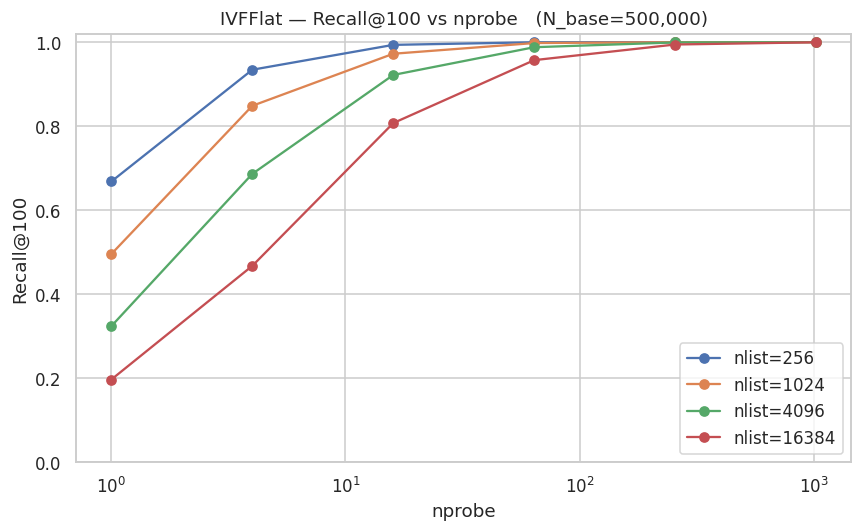

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for nl, sub in df_ivf.groupby('nlist'):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.recall_100, marker='o', label=f'nlist={nl}')
ax.set_xscale('log'); ax.set_xlabel('nprobe'); ax.set_ylabel('Recall@100')
ax.set_title(f'IVFFlat — Recall@100 vs nprobe   (N_base={N_SWEEP:,})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_recall_vs_nprobe.png', dpi=120); plt.show()

### Plot 2 — Heatmap nlist × nprobe → Recall@100

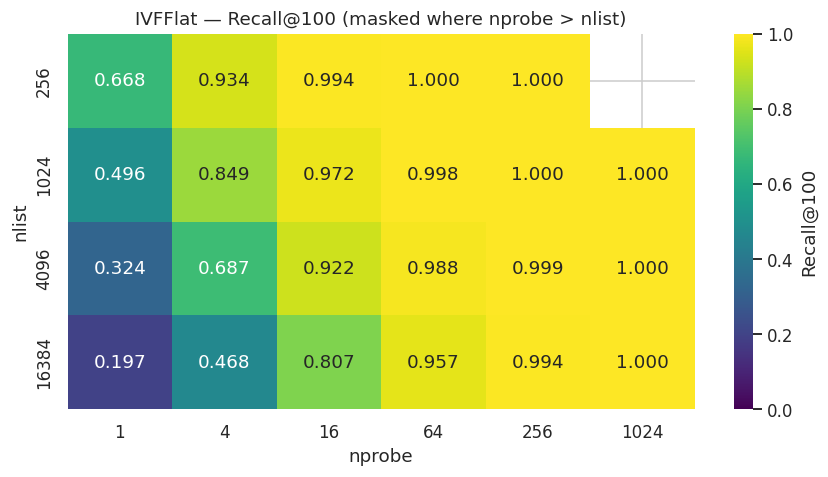

In [11]:
pivot = df_ivf.pivot(index='nlist', columns='nprobe', values='recall_100')
# Invalid IVF configs: nprobe must be ≤ nlist — mask so heatmap shows gaps explicitly
mask_invalid = np.zeros_like(pivot, dtype=bool)
for i, nl in enumerate(pivot.index):
    for j, np_ in enumerate(pivot.columns):
        if int(np_) > int(nl):
            mask_invalid[i, j] = True
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(pivot, mask=mask_invalid, annot=True, fmt='.3f', cmap='viridis', vmin=0, vmax=1,
            ax=ax, cbar_kws={'label': 'Recall@100'})
ax.set_title('IVFFlat — Recall@100 (masked where nprobe > nlist)')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_heatmap.png', dpi=120); plt.show()

### Plot 3 — QPS vs Recall@100 Pareto frontier

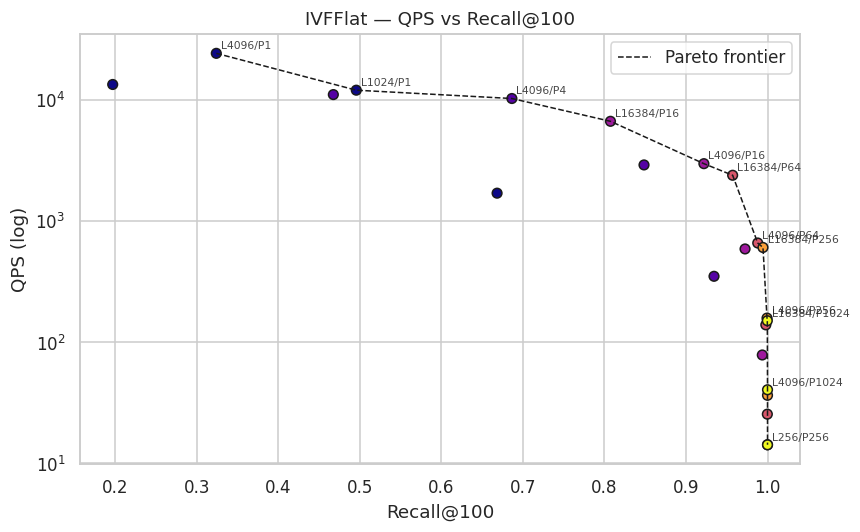

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_ivf.recall_100, df_ivf.qps, c=np.log2(df_ivf.nprobe.values+1),
           cmap='plasma', s=40, edgecolors='k')
mask = utils.pareto_frontier(df_ivf.recall_100.values, df_ivf.qps.values)
order = np.argsort(df_ivf.recall_100.values[mask])
ax.plot(df_ivf.recall_100.values[mask][order], df_ivf.qps.values[mask][order],
        'k--', lw=1, label='Pareto frontier')
# Annotate Pareto points only (avoids clutter)
dfm = df_ivf.iloc[np.where(mask)[0]].sort_values('recall_100')
for _, r in dfm.iterrows():
    ax.annotate(f"L{int(r.nlist)}/P{int(r.nprobe)}", (r.recall_100, r.qps),
                fontsize=7, alpha=0.85, xytext=(3, 3), textcoords='offset points')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVFFlat — QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_pareto.png', dpi=120); plt.show()

### Plot 4 — QPS vs nprobe (per nlist)

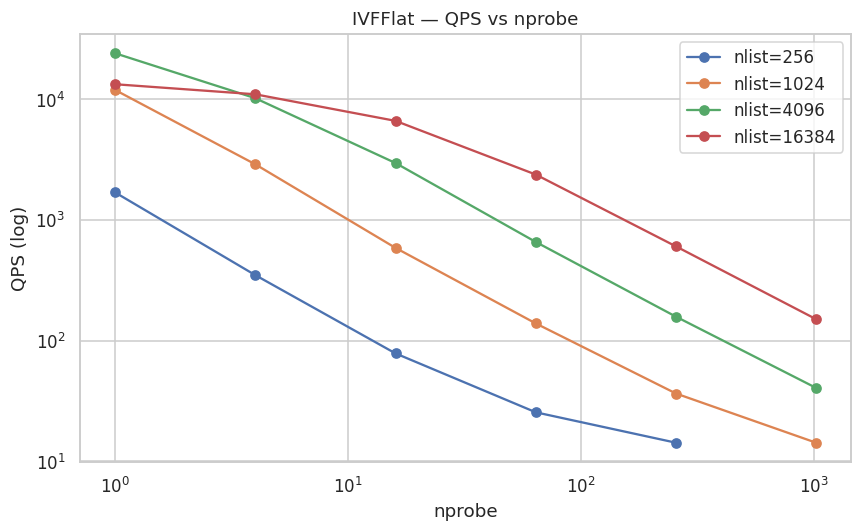

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for nl, sub in df_ivf.groupby('nlist'):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.qps, marker='o', label=f'nlist={nl}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('nprobe'); ax.set_ylabel('QPS (log)')
ax.set_title('IVFFlat — QPS vs nprobe')
ax.legend(); plt.tight_layout()
plt.savefig(DOCS_IMG / '02_ivf_qps_vs_nprobe.png', dpi=120); plt.show()

### Plot 5 — Build time vs nlist

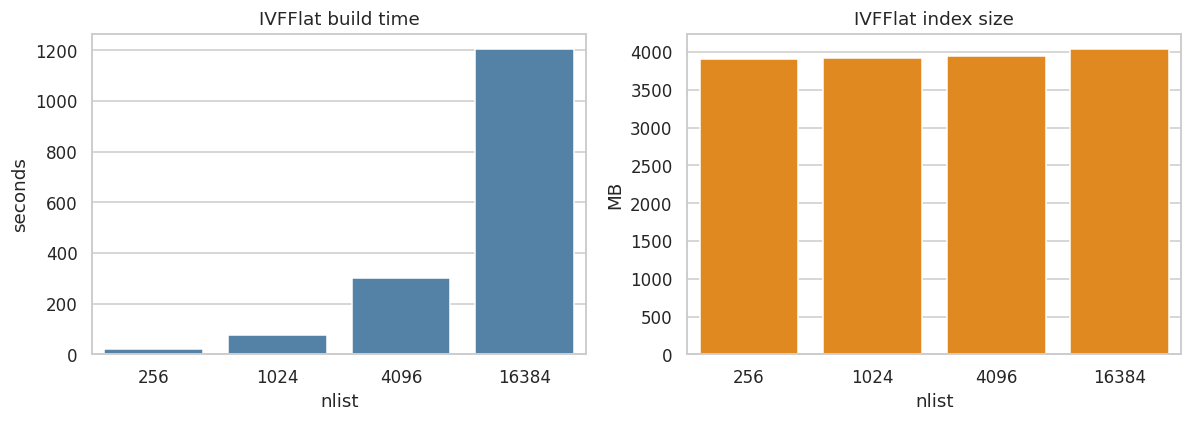

,nlist,build_s,size_mb
0,256,21.950632,3912.066783
1,1024,77.518642,3918.072642
2,4096,303.304120,3942.096080
3,16384,1205.231969,4038.189830


In [14]:
df_bt = df_ivf.drop_duplicates('nlist')[['nlist', 'build_s', 'size_mb']]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_bt, x='nlist', y='build_s', ax=ax[0], color='steelblue')
ax[0].set_title('IVFFlat build time'); ax[0].set_ylabel('seconds')
sns.barplot(data=df_bt, x='nlist', y='size_mb', ax=ax[1], color='darkorange')
ax[1].set_title('IVFFlat index size'); ax[1].set_ylabel('MB')
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_build_size.png', dpi=120); plt.show()
display(df_bt.reset_index(drop=True))

## IVF+PQ sweep — best nlist × PQ M

In [15]:
# Use the nlist with the best recall@100 at the highest tested nprobe as the IVF coarse
# quantiser for both PQ and SQ experiments.
best_nlist = int((df_ivf
              .groupby('nlist')['recall_100'].max()
              .idxmax()))
print(f'using nlist={best_nlist} for IVF+PQ and IVF+SQ')
IVF_PQ_PATH = RESULTS / 'ivf_pq.csv'
utils.init_results_csv(IVF_PQ_PATH)
print('IVFPQ checkpoint:', IVF_PQ_PATH)

using nlist=256 for IVF+PQ and IVF+SQ
IVFPQ checkpoint: results/full/ivf_pq.csv


#### IVF+PQ — M=32

In [16]:
if 32 not in PQ_M_GRID:
    print('skip IVFPQ M=32')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, best_nlist, int(32), int(PQ_NBITS))
    with utils.timed('train+add PQ M=32', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[PQ M={32:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > best_nlist:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=best_nlist, nprobe=nprobe, M=32, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:01<00:09,  1.11s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:02<00:09,  1.23s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:03<00:08,  1.18s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:04<00:06,  1.16s/it]

...

    nprobe=    1  qps= 56719.4  R@100=0.516


    nprobe=    4  qps= 21534.3  R@100=0.584


    nprobe=   16  qps=  6485.9  R@100=0.589


    nprobe=   64  qps=  2389.0  R@100=0.589


    nprobe=  256  qps=  1289.5  R@100=0.589


#### IVF+PQ — M=64

In [17]:
if 64 not in PQ_M_GRID:
    print('skip IVFPQ M=64')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, best_nlist, int(64), int(PQ_NBITS))
    with utils.timed('train+add PQ M=64', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[PQ M={64:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > best_nlist:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=best_nlist, nprobe=nprobe, M=64, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:01<00:12,  1.37s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:03<00:12,  1.56s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:04<00:11,  1.58s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:06<00:08,  1.50s/it]

...

    nprobe=    1  qps= 39867.1  R@100=0.572


    nprobe=    4  qps= 13719.4  R@100=0.676


    nprobe=   16  qps=  3956.7  R@100=0.685


    nprobe=   64  qps=  1240.7  R@100=0.685


    nprobe=  256  qps=   681.4  R@100=0.685


#### IVF+PQ — M=128

In [18]:
if 128 not in PQ_M_GRID:
    print('skip IVFPQ M=128')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFPQ(quant, DIM, best_nlist, int(128), int(PQ_NBITS))
    with utils.timed('train+add PQ M=128', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[PQ M={128:4}]  build {tb.elapsed:6.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > best_nlist:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFPQ', nlist=best_nlist, nprobe=nprobe, M=128, nbits=PQ_NBITS,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_PQ_PATH)

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:02<00:20,  2.32s/it]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:05<00:21,  2.71s/it]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:07<00:18,  2.59s/it]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:10<00:16,  2.67s/it]

...

    nprobe=    1  qps= 21179.5  R@100=0.615


    nprobe=    4  qps=  6422.0  R@100=0.766


    nprobe=   16  qps=  1663.4  R@100=0.782


    nprobe=   64  qps=   576.1  R@100=0.783


    nprobe=  256  qps=   313.3  R@100=0.783


In [19]:
df_pq = pd.read_csv(IVF_PQ_PATH)
display(df_pq.tail(6))

,algo,nlist,nprobe,M,nbits,build_s,size_mb,rss_mb,rss_peak_mb,qps,latency_ms,recall_1,recall_10,recall_100,n_base
9,IVFPQ,256,256,64,8,26.742358,38.334400,10119.660156,10119.660156,681.421259,1.467521,0.4508,0.58242,0.685086,500000
10,IVFPQ,256,1,128,8,38.810838,68.851978,12225.156250,12225.156250,21179.534983,0.047215,0.5362,0.60156,0.615202,500000
11,IVFPQ,256,4,128,8,38.810838,68.851978,12225.156250,12225.156250,6421.964260,0.155716,0.5986,0.69740,0.765896,500000
12,IVFPQ,256,16,128,8,38.810838,68.851978,12225.156250,12225.156250,1663.441756,0.601163,0.6040,0.70532,0.782466,500000
13,IVFPQ,256,64,128,8,38.810838,68.851978,12225.156250,12225.156250,576.136315,1.735700,0.6042,0.70540,0.783184,500000
14,IVFPQ,256,256,128,8,38.810838,68.851978,12225.156250,12225.156250,313.251083,3.192327,0.6042,0.70540,0.783184,500000


### Plot 6 — IVF+PQ Recall@100 vs nprobe (per M)

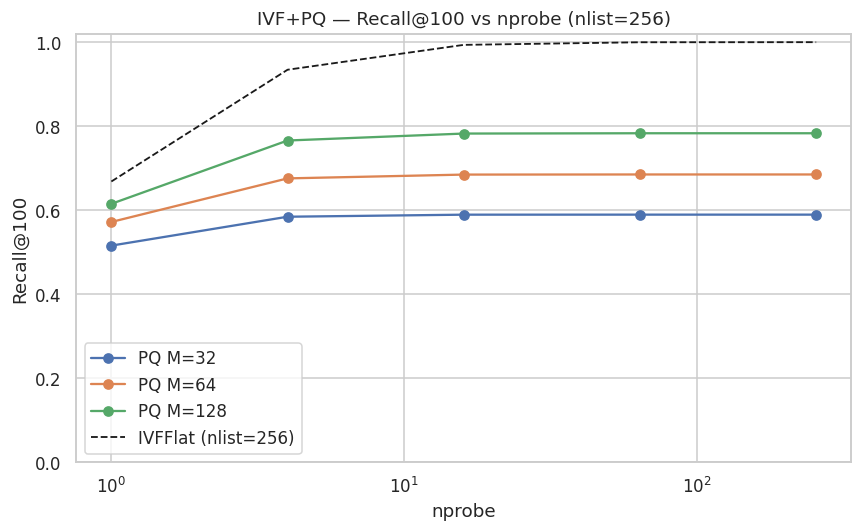

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
for M, sub in df_pq.groupby('M'):
    sub = sub.sort_values('nprobe')
    ax.plot(sub.nprobe, sub.recall_100, marker='o', label=f'PQ M={M}')
# Overlay IVFFlat at the same nlist as upper bound
ref = df_ivf[df_ivf.nlist == best_nlist].sort_values('nprobe')
ax.plot(ref.nprobe, ref.recall_100, 'k--', lw=1.2, label=f'IVFFlat (nlist={best_nlist})')
ax.set_xscale('log'); ax.set_xlabel('nprobe'); ax.set_ylabel('Recall@100')
ax.set_title(f'IVF+PQ — Recall@100 vs nprobe (nlist={best_nlist})')
ax.legend(); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_recall.png', dpi=120); plt.show()

### Plot 7 — IVF+PQ Pareto QPS vs Recall@100 (per M)

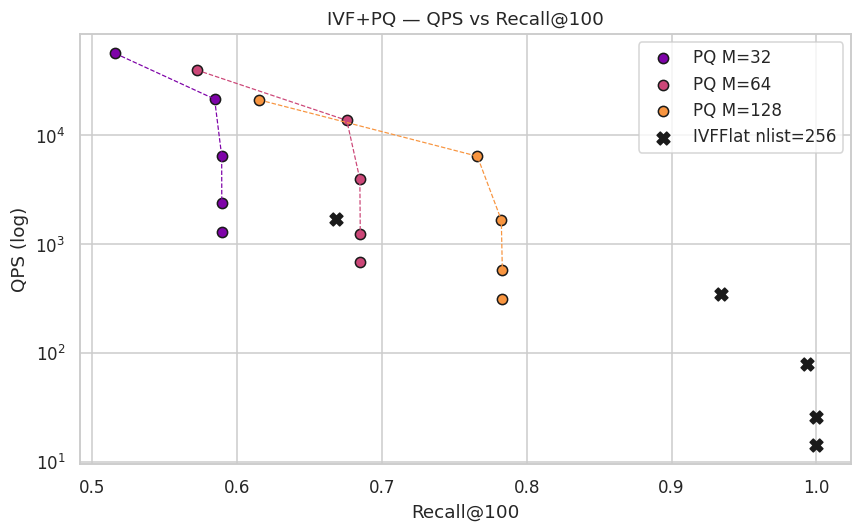

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette('plasma', len(PQ_M_GRID))
for color, (M, sub) in zip(palette, df_pq.groupby('M')):
    ax.scatter(sub.recall_100, sub.qps, color=color, s=45, edgecolors='k', label=f'PQ M={M}')
    ms = utils.pareto_frontier(sub.recall_100.values, sub.qps.values)
    o = np.argsort(sub.recall_100.values[ms])
    ax.plot(sub.recall_100.values[ms][o], sub.qps.values[ms][o], color=color, ls='--', lw=0.8)
ax.scatter(df_ivf[df_ivf.nlist==best_nlist].recall_100, df_ivf[df_ivf.nlist==best_nlist].qps,
           marker='X', color='k', s=70, label=f'IVFFlat nlist={best_nlist}')
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVF+PQ — QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_pareto.png', dpi=120); plt.show()

### Plot 8 — Index size vs PQ M (compression vs flat)

/tmp/ipykernel_297221/3390152941.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_df, x='config', y='size_mb', ax=ax,


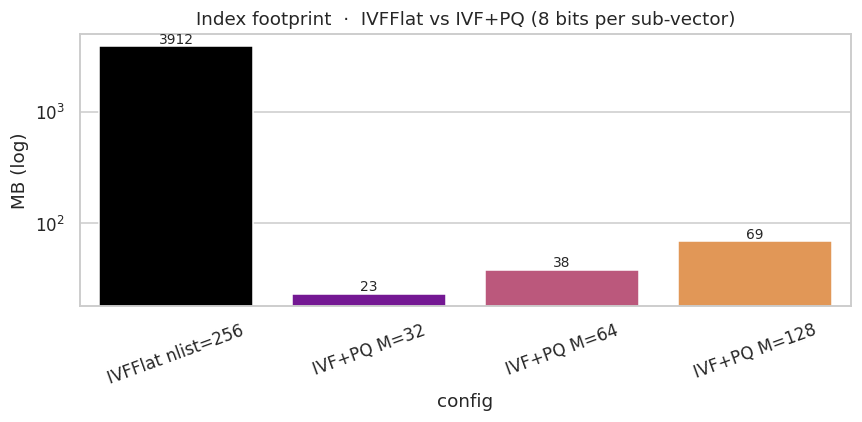

,config,size_mb
0,IVFFlat nlist=256,3912.066783
1,IVF+PQ M=32,23.075611
2,IVF+PQ M=64,38.334400
3,IVF+PQ M=128,68.851978


In [22]:
size_df = pd.concat([
    pd.DataFrame({'config': [f'IVFFlat nlist={best_nlist}'],
                  'size_mb': [df_ivf[df_ivf.nlist==best_nlist].size_mb.iloc[0]]}),
    pd.DataFrame({'config': [f'IVF+PQ M={M}' for M in PQ_M_GRID],
                  'size_mb': [df_pq[df_pq.M==M].size_mb.iloc[0] for M in PQ_M_GRID]}),
]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=size_df, x='config', y='size_mb', ax=ax,
            palette=['black'] + list(sns.color_palette('plasma', len(PQ_M_GRID))))
ax.set_yscale('log'); ax.set_ylabel('MB (log)')
for i, v in enumerate(size_df.size_mb):
    ax.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Index footprint  ·  IVFFlat vs IVF+PQ (8 bits per sub-vector)')
plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivfpq_size.png', dpi=120); plt.show()
display(size_df)

## IVF+ScalarQuantizer

One SQ variant per notebook cell (checkpointed CSV).

In [23]:
IVF_SQ_PATH = RESULTS / 'ivf_sq.csv'
utils.init_results_csv(IVF_SQ_PATH)
print('IVFSQ checkpoint:', IVF_SQ_PATH)

IVFSQ checkpoint: results/full/ivf_sq.csv


#### IVF+SQ — SQ8

In [24]:
if 'SQ8' not in [t[0] for t in SQ_TYPES]:
    print('skip IVFSQ SQ8')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, best_nlist, faiss.ScalarQuantizer.QT_8bit, faiss.METRIC_L2)
    with utils.timed('train+add SQ SQ8', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[SQ SQ8]  build {tb.elapsed:5.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > best_nlist:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ8', nlist=best_nlist, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:00<00:04,  2.06it/s]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:00<00:03,  2.07it/s]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:01<00:03,  2.06it/s]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:01<00:02,  2.06it/s]

...

    nprobe=    1  qps=  7974.4  R@100=0.665


    nprobe=    4  qps=  1657.3  R@100=0.932


    nprobe=   16  qps=   350.8  R@100=0.988


    nprobe=   64  qps=   104.9  R@100=0.993


    nprobe=  256  qps=    56.0  R@100=0.993


#### IVF+SQ — SQ4

In [25]:
if 'SQ4' not in [t[0] for t in SQ_TYPES]:
    print('skip IVFSQ SQ4')
else:
    rows = []
    quant = faiss.IndexFlatL2(DIM)
    idx = faiss.IndexIVFScalarQuantizer(quant, DIM, best_nlist, faiss.ScalarQuantizer.QT_4bit, faiss.METRIC_L2)
    with utils.timed('train+add SQ SQ4', sample_rss_peak=True) as tb:
        idx.train(train_x)
        utils.stream_add(idx, BASE_PATH, N_SWEEP)
    size_mb = utils.index_size_mb(idx)
    rss_peak_mb = tb.rss_peak_mb
    rss_mb = rss_peak_mb
    print(f'[SQ SQ4]  build {tb.elapsed:5.1f}s · size {size_mb:7.1f} MB')
    for nprobe in NPROBE_GRID:
        if nprobe > best_nlist:
            continue
        idx.nprobe = nprobe
        qps, lat_ms, I = utils.measure_qps(
            lambda q,k: idx.search(q,k), queries_sweep, QUERY_K,
            repeat=QPS_REPEAT, warmup=QPS_WARMUP,
        )
        recalls = utils.compute_recalls(I, gt_local[:QUERY_N], (1, 10, 100))
        rows.append(dict(algo='IVFSQ', sq='SQ4', nlist=best_nlist, nprobe=nprobe,
                        build_s=tb.elapsed, size_mb=size_mb, rss_mb=rss_mb, rss_peak_mb=rss_peak_mb,
                        qps=qps, latency_ms=lat_ms,
                        recall_1=recalls[1], recall_10=recalls[10], recall_100=recalls[100],
                        n_base=N_SWEEP))
        print(f'    nprobe={nprobe:5}  qps={qps:8.1f}  R@100={recalls[100]:.3f}')
    del idx, quant; gc.collect()
    utils.append_results(rows, IVF_SQ_PATH)

add (n=500,000, batch=50,000):   0%|                       | 0/10 [00:00<?, ?it/s]

add (n=500,000, batch=50,000):  10%|█▌             | 1/10 [00:00<00:04,  2.06it/s]

add (n=500,000, batch=50,000):  20%|███            | 2/10 [00:00<00:03,  2.05it/s]

add (n=500,000, batch=50,000):  30%|████▌          | 3/10 [00:01<00:03,  2.05it/s]

add (n=500,000, batch=50,000):  40%|██████         | 4/10 [00:01<00:02,  2.07it/s]

...

    nprobe=    1  qps=  6280.6  R@100=0.648


    nprobe=    4  qps=  1477.8  R@100=0.872


    nprobe=   16  qps=   361.7  R@100=0.908


    nprobe=   64  qps=   123.2  R@100=0.912


    nprobe=  256  qps=    68.4  R@100=0.912


In [26]:
df_sq = pd.read_csv(IVF_SQ_PATH)
display(df_sq)

,algo,sq,nlist,nprobe,build_s,size_mb,rss_mb,rss_peak_mb,qps,latency_ms,recall_1,recall_10,recall_100,n_base
0,IVFSQ,SQ8,256,1,11.418677,982.394951,8162.839844,8162.839844,7974.382329,0.125402,0.7576,0.72916,0.665382,500000
1,IVFSQ,SQ8,256,4,11.418677,982.394951,8162.839844,8162.839844,1657.328334,0.603381,0.9550,0.94854,0.932176,500000
2,IVFSQ,SQ8,256,16,11.418677,982.394951,8162.839844,8162.839844,350.750432,2.851030,0.9820,0.98510,0.987954,500000
3,IVFSQ,SQ8,256,64,11.418677,982.394951,8162.839844,8162.839844,104.937855,9.529450,0.9846,0.98778,0.993338,500000
4,IVFSQ,SQ8,256,256,11.418677,982.394951,8162.839844,8162.839844,56.021738,17.850214,0.9846,0.98778,0.993414,500000
5,IVFSQ,SQ4,256,1,11.441054,494.113701,7847.191406,7847.191406,6280.604767,0.159220,0.6354,0.67120,0.647728,500000
6,IVFSQ,SQ4,256,4,11.441054,494.113701,7847.191406,7847.191406,1477.797007,0.676683,0.7718,0.83326,0.871634,500000
7,IVFSQ,SQ4,256,16,11.441054,494.113701,7847.191406,7847.191406,361.726714,2.764518,0.7890,0.85530,0.908232,500000
8,IVFSQ,SQ4,256,64,11.441054,494.113701,7847.191406,7847.191406,123.162838,8.119332,0.7906,0.85670,0.911536,500000
9,IVFSQ,SQ4,256,256,11.441054,494.113701,7847.191406,7847.191406,68.409630,14.617825,0.7906,0.85670,0.911574,500000


### Plot 9 — SQ vs PQ vs Flat at the same nlist (Pareto)

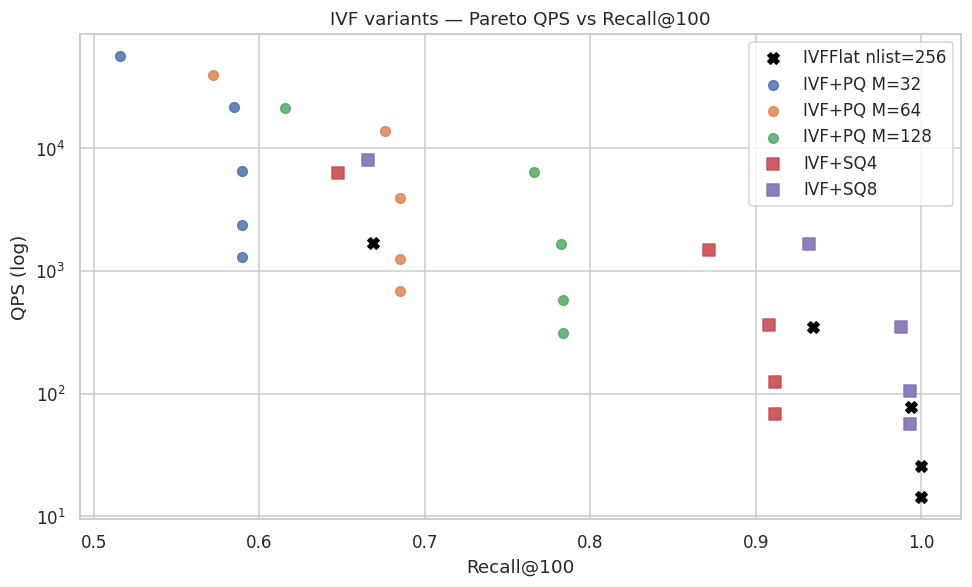

[mem after IVF sweeps]  RSS=2.07 GB  ·  free=24.12 GB  ·  used%=26
rows=48  → results/full/ivf_all.csv


In [27]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(df_ivf[df_ivf.nlist==best_nlist].recall_100, df_ivf[df_ivf.nlist==best_nlist].qps,
           label=f'IVFFlat nlist={best_nlist}', color='black', s=55, marker='X')
for M, sub in df_pq.groupby('M'):
    ax.scatter(sub.recall_100, sub.qps, label=f'IVF+PQ M={M}', s=40, alpha=0.85)
for name, sub in df_sq.groupby('sq'):
    ax.scatter(sub.recall_100, sub.qps, label=f'IVF+{name}', s=70, marker='s', alpha=0.9)
ax.set_yscale('log'); ax.set_xlabel('Recall@100'); ax.set_ylabel('QPS (log)')
ax.set_title('IVF variants — Pareto QPS vs Recall@100')
ax.legend()
plt.tight_layout(); plt.savefig(DOCS_IMG / '02_ivf_all_pareto.png', dpi=120); plt.show()

# Release training slice (~1.6 GB) before notebooks save and plots render.
try:
    del train_x
except NameError:
    pass
gc.collect()
utils.print_mem('after IVF sweeps')

# Persist combined for notebook 05
df_all = pd.concat([df_ivf, df_pq, df_sq], ignore_index=True)
df_all.to_csv(RESULTS / 'ivf_all.csv', index=False)
print(f'rows={len(df_all)}  → {RESULTS / "ivf_all.csv"}')

## Summary

Notable observations to keep in mind when reading `05_comparison.ipynb`:

* The IVFFlat upper bound on Recall@100 is set by `nprobe / nlist`. At the largest
  `nlist`/`nprobe` ratio we should saturate to ≥ 0.99.
* IVF+PQ trades index size for recall — index footprint drops by ~50–100× while
  recall stays within ~10–20 % of Flat **only at high nprobe**.
* IVF+ScalarQuantizer is a middle ground — 4× compression with minimal recall loss.